<a href="https://colab.research.google.com/github/Ganzadidier/Malaria-Diagnosis-CNN-Transfer-Learning/blob/Master/MobileNetV2_Malaria_Diagnosis_CNN_Group6_EvenNumber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Configuration

In [ ]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.19.0


'/device:GPU:0'

## Populating namespaces

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import shutil
import random
import itertools

In [ ]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [ ]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2025-10-04 16:34:01--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.167.192.32, 3.167.192.111, 3.167.192.60, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.167.192.32|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   387MB/s    in 0.9s    

2025-10-04 16:34:02 (387 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  sample_data


## Baseline CNN Model
Define a basic ConvNet defined with ConvLayer: Conv2D => MaxPooling2D followed by Flatten => Dense => Dense(output)

![ConvNet](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/ConvNet.png?raw=1)


# 2. Define Project Paths

In [ ]:
BASE_DIR = '/content/cell_images'
DATA_DIR = os.path.join(BASE_DIR) # Corrected path
TRAIN_DIR = os.path.join(BASE_DIR, 'malaria_dataset/train')
TEST_DIR = os.path.join(BASE_DIR, 'malaria_dataset/test')

print(f"Data Directory: {DATA_DIR}")
print(f"Training Directory: {TRAIN_DIR}")
print(f"Testing Directory: {TEST_DIR}")

Data Directory: /content/cell_images
Training Directory: /content/cell_images/malaria_dataset/train
Testing Directory: /content/cell_images/malaria_dataset/test


# 3. Data Preparation



In [ ]:
# This script splits the data into training and testing sets. It only needs to be run once.
def split_data(source_dir, train_dir, test_dir, split_size=0.8):
    if os.path.exists(train_dir):
        print("Dataset directory already exists. Removing and re-splitting.")
        shutil.rmtree(os.path.dirname(train_dir)) # Remove the parent directory 'malaria_dataset'
    print("Creating new dataset directories...")
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)
    for category in ['Parasitized', 'Uninfected']:
        os.makedirs(os.path.join(train_dir, category), exist_ok=True)
        os.makedirs(os.path.join(test_dir, category), exist_ok=True)
        category_source_path = os.path.join(source_dir, category)
        images = [f for f in os.listdir(category_source_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        random.shuffle(images)
        split_point = int(len(images) * split_size)
        train_images = images[:split_point]
        test_images = images[split_point:]
        for img in train_images:
            shutil.copy(os.path.join(category_source_path, img), os.path.join(train_dir, category, img))
        for img in test_images:
            shutil.copy(os.path.join(category_source_path, img), os.path.join(test_dir, category, img))
    print("Data splitting complete.")

split_data(DATA_DIR, TRAIN_DIR, TEST_DIR)

# ### Create Data Generators
IMG_WIDTH, IMG_HEIGHT = 128, 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Creating new dataset directories...
Data splitting complete.
Found 17638 images belonging to 2 classes.
Found 4408 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.


# 4. MobileNetV2 Model Experiment

In [ ]:
def evaluate_model(model, history, test_generator):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    # Save the learning curves
    plt.savefig('learning_curves.png')
    plt.show()

    Y_pred = model.predict(test_generator)
    y_pred = np.round(Y_pred)
    y_true = test_generator.classes
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Parasitized', 'Uninfected']))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['Parasitized', 'Uninfected'], rotation=45)
    plt.yticks(tick_marks, ['Parasitized', 'Uninfected'])
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    # Save the confusion matrix
    plt.savefig('confusion_matrix.png')
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, Y_pred)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:0.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    # Save the ROC curve
    plt.savefig('roc_curve.png')
    plt.show()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,914,369 (11.12 MB)

 Trainable params: 656,385 (2.50 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 149s 237ms/step - accuracy: 0.7817 - loss: 0.4644 - val_accuracy: 0.8825 - val_loss: 0.2876
Epoch 2/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 106s 191ms/step - accuracy: 0.8725 - loss: 0.3120 - val_accuracy: 0.8947 - val_loss: 0.2770
Epoch 3/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 106s 191ms/step - accuracy: 0.8830 - loss: 0.2878 - val_accuracy: 0.8956 - val_loss: 0.2694
Epoch 4/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 107s 193ms/step - accuracy: 0.8932 - loss: 0.2800 - val_accuracy: 0.8913 - val_loss: 0.2711
Epoch 5/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 105s 190ms/step - accuracy: 0.8877 - loss: 0.2824 - val_accuracy: 0.8988 - val_loss: 0.2575
Epoch 6/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 106s 192ms/step - accuracy: 0.8944 - loss: 0.2671 - val_accuracy: 0.8997 - val_loss: 0.2569
Epoch 7/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 105s 190ms/step - accuracy: 0.8961 - loss: 0.2647 - val_accuracy: 0.9018 - val_loss: 0.2598
Epoch 8/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 143s 192ms/step - accuracy: 0.9030 -

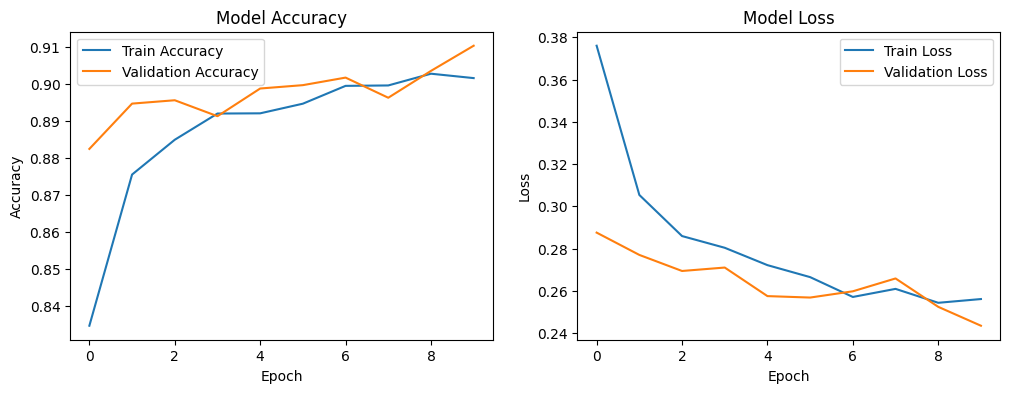

173/173 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step

Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.97      0.81      0.88      2756
  Uninfected       0.84      0.98      0.90      2756

    accuracy                           0.89      5512
   macro avg       0.91      0.89      0.89      5512
weighted avg       0.91      0.89      0.89      5512



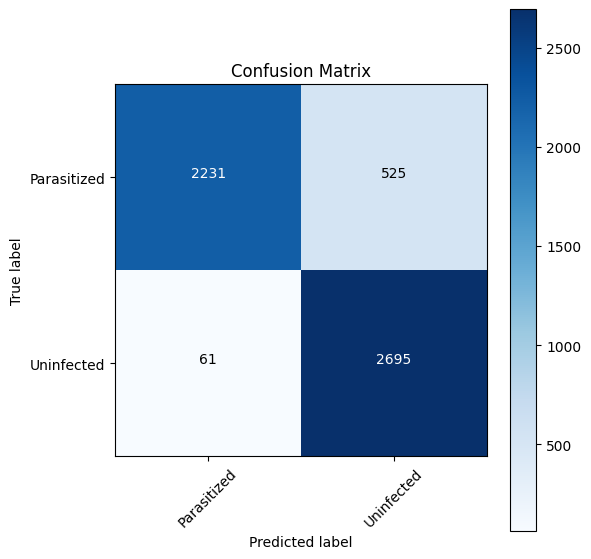

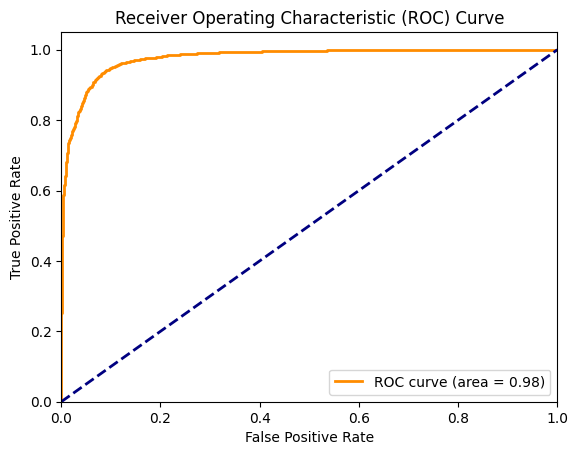

Model saved to malaria_mobilenet_model.h5


In [ ]:
def create_mobilenet_model(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# 1. Create the model
mobilenet_model = create_mobilenet_model()
mobilenet_model.summary()

# 2. Train the model
history_mobilenet = mobilenet_model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# 3. Evaluate the model
evaluate_model(mobilenet_model, history_mobilenet, test_generator)

# Save the trained model
mobilenet_model.save('malaria_mobilenet_model.h5')
print("Model saved to malaria_mobilenet_model.h5")

# 5. MobileNetV2 Model Experiment 2

Number of layers in the model:  158


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,914,369 (11.12 MB)

 Trainable params: 2,400,705 (9.16 MB)

 Non-trainable params: 513,664 (1.96 MB)

Epoch 1/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 147s 229ms/step - accuracy: 0.8705 - loss: 0.3307 - val_accuracy: 0.8462 - val_loss: 0.4374
Epoch 2/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 107s 193ms/step - accuracy: 0.9055 - loss: 0.2516 - val_accuracy: 0.9040 - val_loss: 0.2830
Epoch 3/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 107s 194ms/step - accuracy: 0.9175 - loss: 0.2300 - val_accuracy: 0.9081 - val_loss: 0.2668
Epoch 4/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 107s 194ms/step - accuracy: 0.9226 - loss: 0.2116 - val_accuracy: 0.9158 - val_loss: 0.2427
Epoch 5/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 108s 195ms/step - accuracy: 0.9259 - loss: 0.2039 - val_accuracy: 0.9263 - val_loss: 0.2148
Epoch 6/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 107s 193ms/step - accuracy: 0.9326 - loss: 0.1909 - val_accuracy: 0.9299 - val_loss: 0.1952
Epoch 7/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 107s 193ms/step - accuracy: 0.9320 - loss: 0.1888 - val_accuracy: 0.9319 - val_loss: 0.2003
Epoch 8/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 107s 193ms/step - accuracy: 0.9315 -

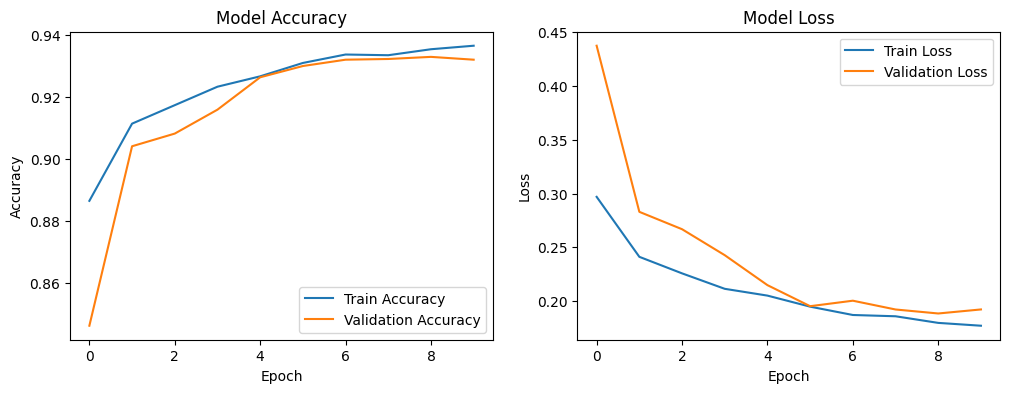

173/173 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step

Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.98      0.92      0.95      2756
  Uninfected       0.92      0.99      0.95      2756

    accuracy                           0.95      5512
   macro avg       0.95      0.95      0.95      5512
weighted avg       0.95      0.95      0.95      5512



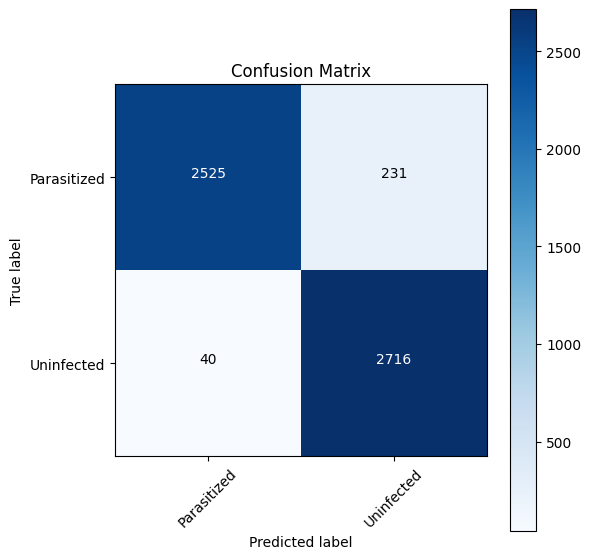

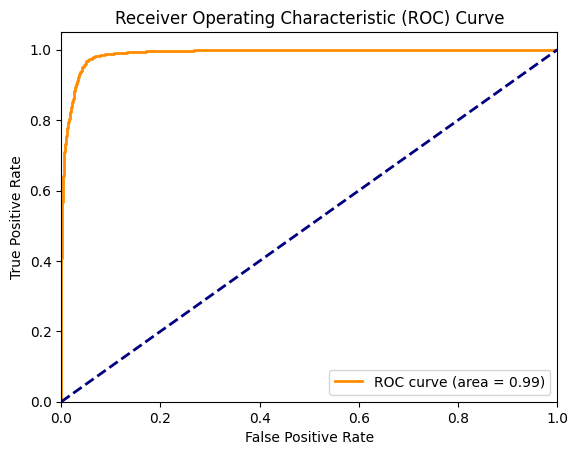

Fine-tuned model saved to malaria_mobilenet_model_tuned.h5


In [ ]:
# Fine-tune the MobileNetV2 model

# Unfreeze some layers of the model
all_layers = mobilenet_model.layers

# Let's take a look to see how many layers are in the model
print("Number of layers in the model: ", len(all_layers))

fine_tune_from_layer = 50

# Unfreeze the layers from
for layer in all_layers[len(all_layers) - fine_tune_from_layer:]:
    layer.trainable = True

# Freeze layers before the fine-tuning point
for layer in all_layers[:len(all_layers) - fine_tune_from_layer]:
    layer.trainable = False


# Recompile the model with a lower learning rate
mobilenet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

mobilenet_model.summary()

# Train the model again with fine-tuning

history_mobilenet_tuned = mobilenet_model.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator
)

# Evaluate the fine-tuned model
evaluate_model(mobilenet_model, history_mobilenet_tuned, test_generator)


mobilenet_model.save('malaria_mobilenet_model_tuned.h5')
print("Fine-tuned model saved to malaria_mobilenet_model_tuned.h5")